# Two-tower recommendations

A movie service wants to rank unseen films for each person. The catalogue has film genres; the service also knows each user's profile and earlier ratings. A two-tower model turns the user-side information and film-side information into vectors, then scores them with a dot product.

We will build and inspect this model on MovieLens 100K. Unlike a lookup table, the towers receive features: age, gender, occupation, a summary of earlier genre ratings, and each film's genre flags. IDs only connect the records.

## 1. Start with one recommendation request

MovieLens has one row per rating event. The event joins a person and a film; the timestamp tells us what came earlier:

| File | Contents | Role in the model |
| --- | --- | --- |
| `u.user` | Age, gender, occupation | Static user features |
| `u.item` | Title and 19 genre flags | Film features |
| `u.data` | User, film, stars, timestamp | History, target, and join keys |

For each rating, the user tower sees the profile plus only that user's earlier ratings. The film tower sees the film's genre flags:

```text
u.user profile + earlier u.data events --> user features --\
                                                             two towers --> predicted stars
u.item genre flags ----------------------> film features --/
current u.data rating -------------------------------------> training target
```

We will train on earlier events, use the second-to-last event per user for validation, and save each user's latest event for a final test. This follows chapter 3's chronological evaluation.

In [17]:
import copy
import csv
from pathlib import Path
import urllib.request
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

torch.manual_seed(7)
RNG = np.random.default_rng(7)

## 2. Build the two feature inputs

### a. Load MovieLens

MovieLens provides separate files for people, films, and ratings. The rating file links a person and a film; the descriptive files tell the towers what each one is like. We will keep the archive in the project cache, as in the earlier MovieLens chapters.

In [18]:
DATASET_DIR = Path(".cache/ml-100k")
archive_path = DATASET_DIR.parent / "ml-100k.zip"

if not DATASET_DIR.exists():
    DATASET_DIR.parent.mkdir(parents=True, exist_ok=True)
    if not archive_path.exists():
        urllib.request.urlretrieve(
            "https://files.grouplens.org/datasets/movielens/ml-100k.zip",
            archive_path,
        )
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(DATASET_DIR.parent)

print(f"Dataset folder: {DATASET_DIR}")

Dataset folder: .cache/ml-100k


### b. Encode the static profile

Each profile contains age scaled to 0-1, two gender flags, and 21 occupation flags: **24 values per user**. The ID only selects this metadata row.

```text
user 1: age 24, gender M, technician
       -> [0.24, F=0, M=1, technician=1, other occupations=0]
```

Demographics describe who the person is, but not necessarily what they like. We will add a compact summary of their earlier ratings after loading the event timeline.

In [19]:
with (DATASET_DIR / "u.user").open(encoding="latin-1", newline="") as file:
    user_profiles = {
        int(row[0]): (int(row[1]), row[2], row[3])
        for row in csv.reader(file, delimiter="|")
    }

OCCUPATIONS = tuple(sorted({profile[2] for profile in user_profiles.values()}))
USER_IDS = np.array(sorted(user_profiles), dtype=int)
USER_INDEX = {int(user_id): row for row, user_id in enumerate(USER_IDS)}

USER_FEATURES = []
for user_id in USER_IDS:
    age, gender, occupation = user_profiles[int(user_id)]
    occupation_flags = [float(occupation == name) for name in OCCUPATIONS]
    USER_FEATURES.append([age / 100, gender == "F", gender == "M", *occupation_flags])
USER_FEATURES = np.asarray(USER_FEATURES, dtype=np.float32)
print(f"{len(USER_IDS):,} users; {USER_FEATURES.shape[1]} features each")

943 users; 24 features each


The profile vector has 24 positions: age, two gender flags, and 21 occupation flags. Most occupation values are zero. This small chart shows only the active fields for user 1, so the encoding is easy to read.

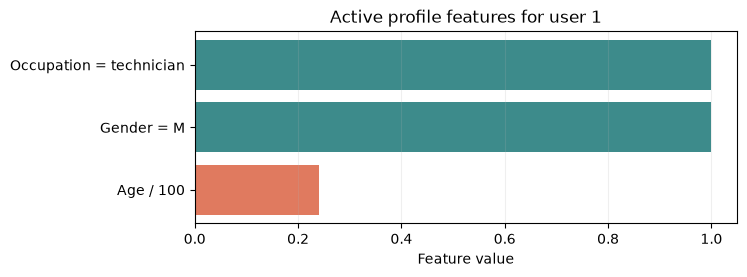

In [20]:
user_id = 1
profile = USER_FEATURES[USER_INDEX[user_id]]
age, gender, occupation = user_profiles[user_id]
gender_column = 1 if gender == "F" else 2
occupation_column = 3 + OCCUPATIONS.index(occupation)

labels = ["Age / 100", f"Gender = {gender}", f"Occupation = {occupation}"]
values = [profile[0], profile[gender_column], profile[occupation_column]]
fig, ax = plt.subplots(figsize=(7, 2.5))
ax.barh(labels, values, color=["#e07a5f", "#3d8b8b", "#3d8b8b"])
ax.set_xlim(0, 1.05)
ax.set_xlabel("Feature value")
ax.set_title("Active profile features for user 1")
ax.grid(axis="x", alpha=0.2)
plt.show()

### c. Describe a film with its genres

Each film has 19 genre flags. A 1 means the genre applies; a 0 means it does not. This is different from a film ID: two films with similar genres begin with similar descriptive inputs, even before we learn their tower vectors.

In [21]:
with (DATASET_DIR / "u.genre").open(encoding="latin-1") as file:
    GENRE_NAMES = tuple(
        line.split("|", 1)[0] for line in file if line.strip()
    )

item_profiles = {}
with (DATASET_DIR / "u.item").open(encoding="latin-1", newline="") as file:
    for row in csv.reader(file, delimiter="|"):
        item_profiles[int(row[0])] = (
            row[1],
            np.asarray(row[5 : 5 + len(GENRE_NAMES)], dtype=np.float32),
        )

ITEM_IDS = np.array(sorted(item_profiles), dtype=int)
ITEM_INDEX = {int(item_id): row for row, item_id in enumerate(ITEM_IDS)}
ITEM_TITLES = {item_id: item_profiles[item_id][0] for item_id in ITEM_IDS}
ITEM_FEATURES = np.stack(
    [item_profiles[int(item_id)][1] for item_id in ITEM_IDS]
)
print(f"{len(ITEM_IDS):,} films; {ITEM_FEATURES.shape[1]} genre flags each")

1,682 films; 19 genre flags each


Toy Story's genre vector has 1s for Animation, Children's, and Comedy, and 0s for the other genres. We plot only the active flags; the full vector still has 19 values.

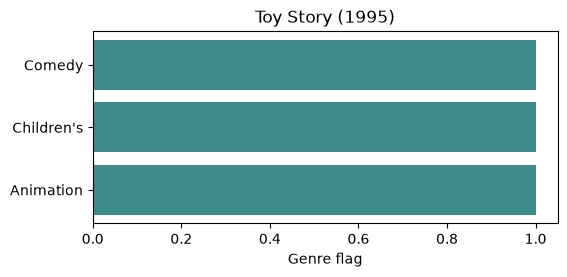

In [22]:
film_id = 1
film_row = ITEM_INDEX[film_id]
active_genres = np.flatnonzero(ITEM_FEATURES[film_row])
film_genres = [GENRE_NAMES[index] for index in active_genres]

fig, ax = plt.subplots(figsize=(6, 2.5))
ax.barh(film_genres, np.ones(len(film_genres)), color="#3d8b8b")
ax.set_xlim(0, 1.05)
ax.set_xlabel("Genre flag")
ax.set_title(f"{ITEM_TITLES[film_id]}")
plt.show()

## 3. Hold out the future

Chapter 3 hides each user's latest rating. We will do the same, and also reserve the rating immediately before it for validation. The model sees neither while fitting:

```text
one user's history, in time order
older ratings ---------------- second-to-last ---- last
       TRAIN                    VALIDATION         TEST
```

Validation shows whether learning is helping on later interactions. The test rating stays untouched until the final performance comparison. This avoids the random split used in the previous draft and matches the evaluation story from chapter 3.

In [36]:
events = np.loadtxt(
    DATASET_DIR / "u.data", usecols=(0, 1, 2, 3), dtype=np.int64
)
events = events[np.argsort(events[:, 3], kind="stable")]

validation_rows, test_rows = [], []
for user_id in USER_IDS:
    user_rows = np.flatnonzero(events[:, 0] == user_id)
    validation_rows.append(user_rows[-2])
    test_rows.append(user_rows[-1])
validation_rows = np.asarray(validation_rows, dtype=int)
test_rows = np.asarray(test_rows, dtype=int)

reserved_rows = np.zeros(len(events), dtype=bool)
reserved_rows[validation_rows] = True
reserved_rows[test_rows] = True
train_rows = np.flatnonzero(~reserved_rows)
train_events = events[train_rows]
validation_events = events[validation_rows]
test_events = events[test_rows]
print(f"Train: {len(train_rows):,}; validation: {len(validation_rows):,}; test: {len(test_rows):,}")

Train: 98,114; validation: 943; test: 943


The split contains 98,114 training ratings, 943 validation ratings, and 943 test ratings. To give the tower individual taste information, we summarize earlier ratings as a preference value for each genre. Ratings above 3 push a genre positive; ratings below 3 push it negative. For each event, this summary is calculated **before** adding the current rating, so future ratings cannot leak into the input.

In [37]:
history_totals = np.zeros((len(USER_IDS), len(GENRE_NAMES)), dtype=np.float32)
history_counts = np.zeros_like(history_totals)
EVENT_USER_FEATURES = np.empty(
    (len(events), USER_FEATURES.shape[1] + len(GENRE_NAMES)), dtype=np.float32
)

for event_row, (user_id, item_id, rating, _) in enumerate(events):
    user_row = USER_INDEX[int(user_id)]
    genre_history = np.divide(
        history_totals[user_row],
        history_counts[user_row],
        out=np.zeros_like(history_totals[user_row]),
        where=history_counts[user_row] > 0,
    )
    EVENT_USER_FEATURES[event_row] = np.concatenate(
        (USER_FEATURES[user_row], genre_history)
    )
    genre_flags = ITEM_FEATURES[ITEM_INDEX[int(item_id)]]
    history_totals[user_row] += genre_flags * ((rating - 3) / 2)
    history_counts[user_row] += genre_flags

print(f"User tower input per event: {EVENT_USER_FEATURES.shape[1]} features")

User tower input per event: 43 features


Here is user 1's genre-preference history just before their final rating. Values are averages centered at a neutral rating of 3: positive bars indicate genres rated above 3, negative bars below 3.

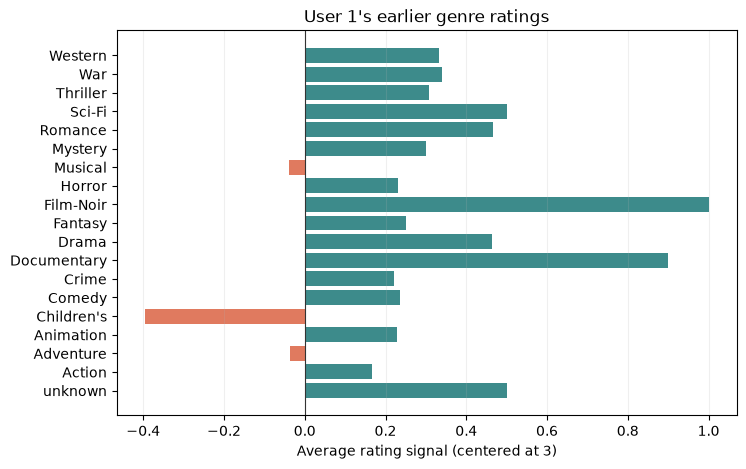

In [38]:
user_id = 1
history_start = USER_FEATURES.shape[1]
user_genre_history = EVENT_USER_FEATURES[
    test_rows[USER_INDEX[user_id]], history_start:
]
bar_colors = ["#3d8b8b" if value >= 0 else "#e07a5f" for value in user_genre_history]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(GENRE_NAMES, user_genre_history, color=bar_colors)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set(xlabel="Average rating signal (centered at 3)", title="User 1's earlier genre ratings")
ax.grid(axis="x", alpha=0.2)
plt.show()

In [39]:
def make_feature_batches(event_rows):
    batch_events = events[event_rows]
    user_features = torch.from_numpy(EVENT_USER_FEATURES[event_rows])
    item_rows = np.array([ITEM_INDEX[int(row[1])] for row in batch_events])
    item_features = torch.from_numpy(ITEM_FEATURES[item_rows])
    targets = torch.from_numpy(batch_events[:, 2].astype(np.float32))
    return user_features, item_features, targets


train_users, train_items, train_ratings = make_feature_batches(train_rows)
valid_users, valid_items, valid_ratings = make_feature_batches(validation_rows)
test_users, test_items, test_ratings = make_feature_batches(test_rows)
print("Feature batches:", train_users.shape, train_items.shape)

Feature batches: torch.Size([98114, 43]) torch.Size([98114, 19])


## 4. Two towers, one comparison space

The user tower combines 24 profile values with 19 preferences from earlier ratings: **43 inputs**. The film tower receives 19 genre flags. Each network maps its different input to a 32-value vector:

```text
profile (24) + earlier genre taste (19) --> user tower --> u (32) --\
                                                                      dot product --> score
film genres (19) ------------------------> film tower --> v (32) --/
```

The coordinates are learned from rating examples. They are not one-to-one labels like "comedy" or "age". Both towers must output vectors of the same length so their dot product is defined.

In [41]:
embedding_dim = 32

user_tower = nn.Sequential(
    nn.Linear(EVENT_USER_FEATURES.shape[1], embedding_dim),
    nn.ReLU(),
    nn.Linear(embedding_dim, embedding_dim),
)
item_tower = nn.Sequential(
    nn.Linear(ITEM_FEATURES.shape[1], embedding_dim),
    nn.ReLU(),
    nn.Linear(embedding_dim, embedding_dim),
)


def score_pairs(user_features, item_features):
    user_vectors = user_tower(user_features)
    item_vectors = item_tower(item_features)
    return (user_vectors * item_vectors).sum(dim=1)

In [42]:
example_users = user_tower(train_users[:4])
example_films = item_tower(train_items[:4])
example_scores = (example_users * example_films).sum(dim=1)

print("Vector shapes:", tuple(example_users.shape), tuple(example_films.shape))
print("Observed stars:", train_ratings[:4])
print("Initial scores:", example_scores.detach().round(decimals=2))

Vector shapes: (4, 32) (4, 32)
Observed stars: tensor([4., 4., 4., 4.])
Initial scores: tensor([-0.0600, -0.1300, -0.0500, -0.1200])


## 5. Train by matching ratings

For each training event, the user tower sees a profile plus earlier genre preferences; the film tower sees genre flags. Their dot product predicts stars. Mean squared error (MSE) measures the gap from the observed rating:

$$
\operatorname{MSE}=\frac{1}{N}\sum_{i=1}^{N}(\widehat r_i-r_i)^2
$$

```text
user profile + past taste + film genres --> towers --> predicted stars
observed stars ---------------------------> compare --> MSE --> gradients
                                                               update both
```

First, take one small batch through the loop. This makes `backward()` and `step()` concrete before training for multiple epochs.

In [43]:
optimizer = torch.optim.Adam(
    [*user_tower.parameters(), *item_tower.parameters()], lr=1e-3
)
batch_rows = torch.arange(256)

optimizer.zero_grad()
batch_scores = score_pairs(train_users[batch_rows], train_items[batch_rows])
batch_loss = nn.functional.mse_loss(batch_scores, train_ratings[batch_rows])
loss_before = batch_loss.item()
batch_loss.backward()
optimizer.step()

with torch.no_grad():
    scores_after = score_pairs(train_users[batch_rows], train_items[batch_rows])
    loss_after = nn.functional.mse_loss(scores_after, train_ratings[batch_rows])
print(f"One batch MSE: {loss_before:.3f} -> {loss_after.item():.3f}")

One batch MSE: 17.597 -> 17.343


The output shows whether this small update reduced error on the batch it just saw. That is a local training check, not evidence of generalization. The train/validation curve below answers the next question: does prediction error also improve on later ratings excluded from updates?

In [44]:
def rmse(predictions, targets):
    return torch.sqrt(nn.functional.mse_loss(predictions, targets)).item()


def train_epoch(batch_size):
    order = torch.randperm(len(train_ratings))
    for start in range(0, len(order), batch_size):
        rows = order[start : start + batch_size]
        predictions = score_pairs(train_users[rows], train_items[rows])
        loss = nn.functional.mse_loss(predictions, train_ratings[rows])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

### a. Track learning and generalization

An **epoch** is one pass over the training ratings. Training RMSE says how well the model fits the examples it learns from; validation RMSE says how well it predicts later examples it did not train on. If training keeps improving while validation gets worse, the model is starting to memorize.

We will also draw the validation RMSE of a constant predictor (the mean training rating). The test events remain untouched until the next section.

In [45]:
epochs = 20
batch_size = 4096
history = {"training": [], "validation": []}
best_validation_rmse = float("inf")
best_epoch = 0
best_user_state = None
best_item_state = None
validation_mean = train_ratings.mean()
validation_baseline_rmse = rmse(torch.full_like(valid_ratings, validation_mean), valid_ratings)
print(f"Mean-rating validation RMSE: {validation_baseline_rmse:.3f} stars")

Mean-rating validation RMSE: 1.189 stars


In [46]:
for epoch in range(epochs):
    train_epoch(batch_size)
    with torch.no_grad():
        train_prediction = score_pairs(train_users, train_items)
        valid_prediction = score_pairs(valid_users, valid_items)
    history["training"].append(rmse(train_prediction, train_ratings))
    validation_rmse = rmse(valid_prediction, valid_ratings)
    history["validation"].append(validation_rmse)

    if validation_rmse < best_validation_rmse:
        best_validation_rmse = validation_rmse
        best_epoch = epoch + 1
        best_user_state = copy.deepcopy(user_tower.state_dict())
        best_item_state = copy.deepcopy(item_tower.state_dict())

user_tower.load_state_dict(best_user_state)
item_tower.load_state_dict(best_item_state)
print(f"Best validation RMSE: {best_validation_rmse:.3f} stars at epoch {best_epoch}")

Best validation RMSE: 1.092 stars at epoch 20


### b. Read the learning curve

This plot has a different job from the chapter 1–3 recommendation curves: it shows how optimization changes prediction error over epochs. The training line measures fit to examples used for updates; validation is the guard against memorizing them. The dashed line is the simple mean-rating baseline.

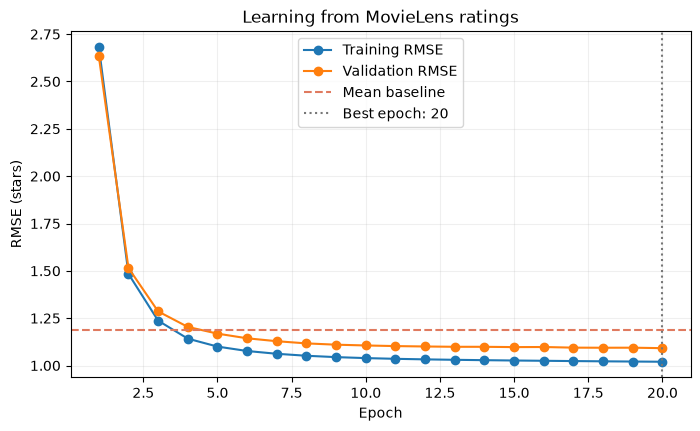

In [47]:
epoch_numbers = np.arange(1, epochs + 1)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(epoch_numbers, history["training"], marker="o", label="Training RMSE")
ax.plot(epoch_numbers, history["validation"], marker="o", label="Validation RMSE")
ax.axhline(validation_baseline_rmse, color="#e07a5f", linestyle="--", label="Mean baseline")
ax.axvline(best_epoch, color="#777777", linestyle=":", label=f"Best epoch: {best_epoch}")
ax.set(xlabel="Epoch", ylabel="RMSE (stars)", title="Learning from MovieLens ratings")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## 6. Measure test performance

The test set contains each user's latest rating and was not used for training or checkpoint selection. We report two different questions, as in chapter 3:

- **RMSE:** how close are predicted stars to the held-out rating? Compare with the training-set mean.
- **HitRate@10:** for held-out ratings of 4 or 5 on films not previously rated, did the film appear in the top ten unseen recommendations? Compare with popularity.

These metrics are not interchangeable. A model can predict ratings well without ranking the exact future film in its top ten.

In [48]:
with torch.no_grad():
    test_predictions = score_pairs(test_users, test_items)

two_tower_rmse = rmse(test_predictions, test_ratings)
mean_rating = train_ratings.mean()
mean_baseline_rmse = rmse(torch.full_like(test_ratings, mean_rating), test_ratings)
print(f"Test RMSE, training mean: {mean_baseline_rmse:.3f} stars")
print(f"Test RMSE, two towers:    {two_tower_rmse:.3f} stars")

Test RMSE, training mean: 1.213 stars
Test RMSE, two towers:    1.105 stars


The score is smaller for better rating prediction. This first plot compares only the two rating predictors; the next plot uses HitRate@10, where larger is better.

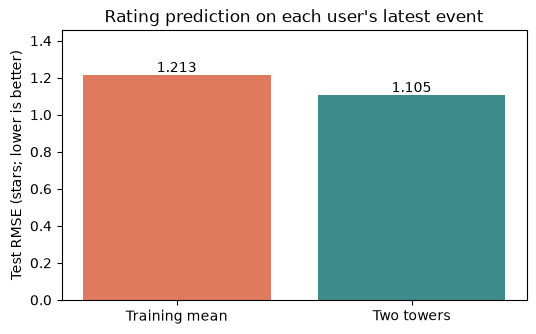

In [49]:
rmse_labels = ["Training mean", "Two towers"]
rmse_values = [mean_baseline_rmse, two_tower_rmse]
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(rmse_labels, rmse_values, color=["#e07a5f", "#3d8b8b"])
ax.bar_label(bars, fmt="%.3f")
ax.set_ylabel("Test RMSE (stars; lower is better)")
ax.set_title("Rating prediction on each user's latest event")
ax.set_ylim(0, max(rmse_values) * 1.2)
plt.show()

RMSE alone does not tell us whether the right films reached the shortlist. This second chart measures the share of unseen future favorites found in each method's top ten.

### a. Cache film vectors and hide seen films

The film tower is independent of the current request, so encode each film once. At request time, encode the user's profile plus earlier genre preferences and compare that query with cached film vectors. Remove films already rated before the held-out event.

Popularity is the ranking baseline: order films by the number of positive training ratings.

In [50]:
with torch.no_grad():
    CATALOGUE_VECTORS = item_tower(torch.from_numpy(ITEM_FEATURES))

seen_by_user = {}
for user_id in USER_IDS:
    user_rows = np.flatnonzero(events[:, 0] == user_id)
    seen_by_user[int(user_id)] = {
        int(item_id) for item_id in events[user_rows[:-1], 1]
    }

train_item_rows = np.array([ITEM_INDEX[int(row[1])] for row in train_events])
positive_counts = np.bincount(
    train_item_rows[train_events[:, 2] >= 4], minlength=len(ITEM_IDS)
)
POPULAR_ITEM_ROWS = np.argsort(-positive_counts, kind="stable")
print("Cached catalogue vectors:", tuple(CATALOGUE_VECTORS.shape))

Cached catalogue vectors: (1682, 32)


### b. Rank unseen films for a user

At request time, the ID is used only to retrieve the profile, the earlier-genre-history vector, and the set of films already seen. Those features go to the tower; the ID does not.

In [51]:
def recommend_two_tower(user_id, k=10):
    event_row = test_rows[USER_INDEX[user_id]]
    user_features = torch.from_numpy(EVENT_USER_FEATURES[event_row])
    with torch.no_grad():
        query_vector = user_tower(user_features)
        scores = CATALOGUE_VECTORS @ query_vector
    candidates = [
        row for row, item_id in enumerate(ITEM_IDS)
        if int(item_id) not in seen_by_user[user_id]
    ]
    candidate_scores = scores[candidates]
    positions = torch.topk(candidate_scores, k=min(k, len(candidates))).indices.tolist()
    return [
        (int(ITEM_IDS[candidates[pos]]), float(candidate_scores[pos]))
        for pos in positions
    ]


def recommend_popular(user_id, k=10):
    unseen = [
        row for row in POPULAR_ITEM_ROWS
        if int(ITEM_IDS[row]) not in seen_by_user[user_id]
    ]
    return [int(ITEM_IDS[row]) for row in unseen[:k]]

### c. Did the shortlist include a future favorite?

A held-out rating of 4 or 5 is a positive event. We count a hit when that film appears in the user's top ten unseen films. Popularity is scored on the same users and candidates.

In [52]:
positive_test_events = [
    (int(row[0]), int(row[1]))
    for row in test_events
    if row[2] >= 4 and int(row[1]) not in seen_by_user[int(row[0])]
]
tower_hits = 0
popular_hits = 0
for user_id, future_item_id in positive_test_events:
    tower_hits += future_item_id in [
        item_id for item_id, _ in recommend_two_tower(user_id, k=10)
    ]
    popular_hits += future_item_id in recommend_popular(user_id, k=10)

tower_hit_rate = tower_hits / len(positive_test_events)
popular_hit_rate = popular_hits / len(positive_test_events)
print(f"Unseen positive test events: {len(positive_test_events)}")
print(f"Popular HitRate@10: {popular_hit_rate:.3f}")
print(f"Two-tower HitRate@10: {tower_hit_rate:.3f}")

Unseen positive test events: 486
Popular HitRate@10: 0.109
Two-tower HitRate@10: 0.023


Compare ranking separately from rating prediction. Here, a hit means a future 4-or-5-star film appeared among the user's top ten unseen films.

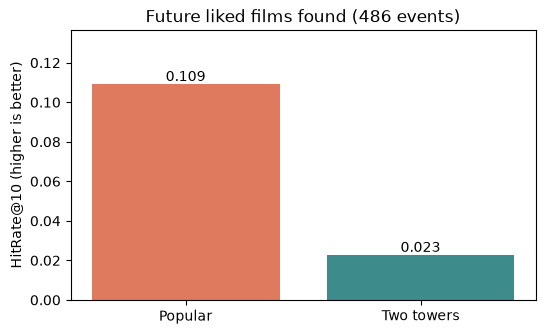

In [54]:
hit_labels = ["Popular", "Two towers"]
hit_values = [popular_hit_rate, tower_hit_rate]
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(hit_labels, hit_values, color=["#e07a5f", "#3d8b8b"])
ax.bar_label(bars, fmt="%.3f")
ax.set_ylabel("HitRate@10 (higher is better)")
ax.set_title(f"Future liked films found ({len(positive_test_events)} events)")
ax.set_ylim(0, max(hit_values) * 1.25)
plt.show()

Here the two-tower model's HitRate@10 is below popularity. That is an important result: training to predict stars with MSE does not automatically produce a good top-K ranker. A retrieval system may need a ranking objective, stronger features, or both. The RMSE plot and this plot answer different questions.

## 7. Inspect one ranked shortlist

Now we can follow one request end to end. User 1's profile and genre history create a query vector; the cached film vectors are scored and already-rated films removed. The horizontal bars show the top five remaining films.

In [ ]:
user_id = 1
test_event_row = test_rows[USER_INDEX[user_id]]
user_features = torch.from_numpy(EVENT_USER_FEATURES[test_event_row])
with torch.no_grad():
    query_vector = user_tower(user_features)
    film_scores = CATALOGUE_VECTORS @ query_vector

unseen_rows = [
    row for row, item_id in enumerate(ITEM_IDS)
    if int(item_id) not in seen_by_user[user_id]
]
top_rows = torch.topk(film_scores[unseen_rows], k=5).indices.tolist()
top_rows = [unseen_rows[position] for position in top_rows]
top_titles = [ITEM_TITLES[int(ITEM_IDS[row])] for row in top_rows]
top_scores = [film_scores[row].item() for row in top_rows]
for title, score in zip(top_titles, top_scores):
    print(f"{score:.2f}  {title}")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(top_titles[::-1], top_scores[::-1], color="#3d8b8b")
ax.set_xlabel("Two-tower score (higher ranks first)")
ax.set_title("Top five unseen films for user 1")
ax.grid(axis="x", alpha=0.2)
plt.show()

## Your turn

1. Remove the 19 genre-history values and compare HitRate@10 with popularity.
2. Change `embedding_dim` from 32 to 8 or 64. Compare train and validation curves.
3. Compare HitRate@5, @10, and @20.
4. Add release year to film features and handle missing dates.

## In summary

- The user tower combines profile and earlier genre preferences; the film tower uses genre flags.
- IDs join records and filter seen films; they are not tower inputs.
- Both towers map to 32-value vectors and score pairs with a dot product.
- Chronological validation guides training; the latest rating per user is reserved for test.
- RMSE measures star prediction, while HitRate@10 measures shortlist coverage. Compare each to its own baseline.